### **Week 10 Wednesday: SQL JOIN Operations (Connecting Your Data Across Tables)**

**Today's Objectives**

- Understand why we need JOIN operations in relational databases

- Master the 4 main JOIN types: INNER, LEFT, RIGHT, and FULL

- Learn how to combine data from multiple tables

- Solve real-world data problems using JOINs

- Practice joining 3+ tables for complex queries



### **1. Why Do We Need JOINs?**

**The Problem:** Data is Spread Across Tables

**Our Current Tables:**

- users - User information

- tasks - Task details

- categories - Task categories

- task_categories - Connections between tasks and categories

**The Question:** How do we see tasks with usernames instead of user IDs?

**Before JOINs:**

**users table**

| user_id | username |
| ------- | -------- |
| 1       | alice    |
| 2       | bob      |

**tasks table:**

| task_id | title     | user_id |
| ------- | --------- | ------- |
| 1       | Learn SQL | 1       |
| 2       | Build App | 2       |

**Joined table:**

| task_id | title     | username |
| ------- | --------- | -------- |
| 1       | Learn SQL | alice    |
| 2       | Build App | bob      |



In [ ]:
-- Create Students table
CREATE TABLE students (
    student_id INTEGER PRIMARY KEY,
    name TEXT
);

-- Create Enrollments table
CREATE TABLE enrollments (
    student_id INTEGER,
    course TEXT
);

-- Insert into Students
INSERT INTO students (student_id, name)
VALUES 
    (1, 'Alice'),
    (2, 'Bob'),
    (3, 'Cara');

-- Professor's 부가설명 
-- 문제: 테이블 두 번 만들어진 친굴들 있었음
-- 해결방법:
-- 이걸 두 번 누를 시, 하단 result에 table 두 번 생김
-- PRIMARY KEY는 unique한 것 따라서 이걸로 해결할 수 있음'
-- 또한, 그저 'Drop'누르는 방법도 있고 SERIAL 의미는 'remain'임 
-- StudentID 1,2,3,4 세로로 쫙 있을 때 SERIAL로 처리할 수 있다 
-- table의 customers 칸에서 'Drop' 키 누르면 된다 

-- Insert into Enrollments
INSERT INTO enrollments (student_id, course)
VALUES
    (2, 'Database 101'),
    (3, 'Python Basics'),
    (4, 'Web Design');

### **The Basic JOIN Syntax**

```sql
SELECT columns
FROM table1
JOIN table2 ON table1.column = table2.column;


We’ll use two simple tables to explore the four main types of SQL JOINs shown in the diagram below.  

---

### Base Tables

**Table A: `Students`**

| student_id | name  |
|-------------|-------|
| 1           | Alice |
| 2           | Bob   |
| 3           | Cara  |

**Table B: `Enrollments`**

| student_id | course        |
|-------------|---------------|
| 2           | Database 101  |
| 3           | Python Basics |
| 4           | Web Design    |

---


### **2. Inner join (The most commonly used)**

**What it does:**

Returns only rows where there's a match in BOTH tables

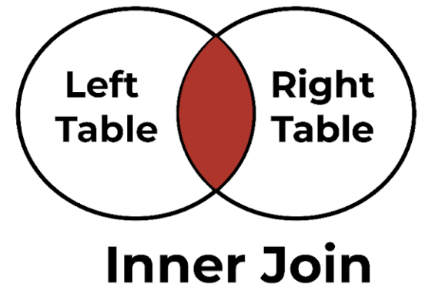


In [ ]:
SELECT Students.student_id, Students.name, Enrollments.course
FROM Students
INNER JOIN Enrollments
ON Students.student_id = Enrollments.student_id;

-- Because in your python code, if you want to 'add' by default 
-- 교수님 질문 답: ORDER BY

**Result:**

| student_id | name | course        |
| ---------- | ---- | ------------- |
| 2          | Bob  | Database 101  |
| 3          | Cara | Python Basics |


### **3. LEFT JOIN (Very Useful)**

**What it does:**

Returns ALL rows from the left table, plus matching rows from the right table

If no matching enrollment exists, show NULL for course.

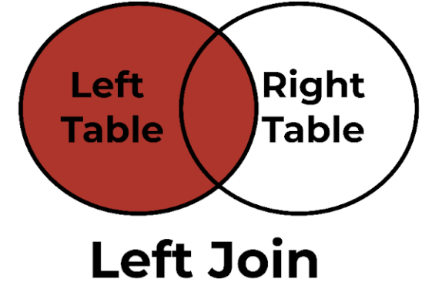


In [ ]:
SELECT Students.student_id, Students.name, Enrollments.course
FROM Students
LEFT JOIN Enrollments
ON Students.student_id = Enrollments.student_id;

**Results:**

| student_id | name  | course        |
| ---------- | ----- | ------------- |
| 1          | Alice | **NULL**      |
| 2          | Bob   | Database 101  |
| 3          | Cara  | Python Basics |

**Explanation:**

- Everyone from the Students table is listed.

- Unmatched rows (like Alice) have NULL for course.

### **4. RIGHT JOIN (Less Common)**

**What it does:**

Returns ALL rows from the right table, plus matching rows from the left table

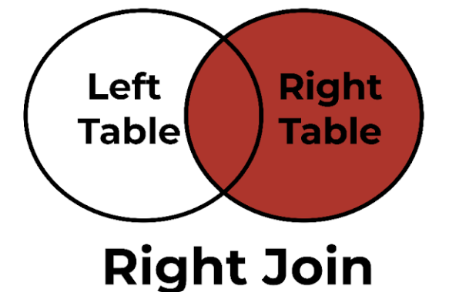


In [ ]:
SELECT Students.student_id, Students.name, Enrollments.course
FROM Students
RIGHT JOIN Enrollments --여기서는 JOIN만 바뀐 것 
ON Students.student_id = Enrollments.student_id;


**Result:**

| student_id | name     | course        |
| ---------- | -------- | ------------- |
| 2          | Bob      | Database 101  |
| 3          | Cara     | Python Basics |
| NULL       | **NULL** | Web Design    |

**Explanation:**

- Every course enrollment is displayed.

- Student 4 has no record in Students, so their name is NULL.

### **4. FULL JOIN (Rarely Used)**

**What it does:**

Returns ALL rows from BOTH tables, with matches where they exist

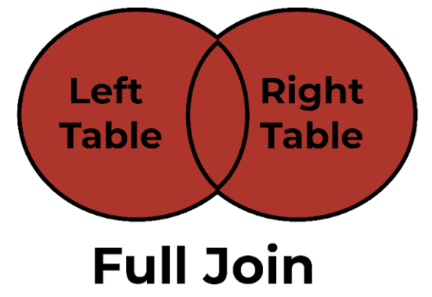


**What it does:**

Return all rows from both tables — match where possible, fill NULLs where not.

In [ ]:
SELECT 
    s.student_id,
    s.name,
    e.course
FROM students s
FULL OUTER JOIN enrollments e
ON s.student_id = e.student_id;

**Result:**

| student_id | name     | course        |
| ---------- | -------- | ------------- |
| 1          | Alice    | **NULL**      |
| 2          | Bob      | Database 101  |
| 3          | Cara     | Python Basics |
| NULL       | **NULL** | Web Design    |

**Explanation:**

- Combines everything — all students and all enrollments.

- Missing matches are filled with NULL.

## Summary Table


| JOIN Type      | Rows Returned                                     |
| -------------- | ------------------------------------------------- |
| **INNER JOIN** | Only matching rows from both tables               |
| **LEFT JOIN**  | All rows from left table, plus matches from right |
| **RIGHT JOIN** | All rows from right table, plus matches from left |
| **FULL JOIN**  | All rows from both tables, matched where possible |


### Quick Analogy (Easy to Remember)


| Join Type      | Real-World Example                                |
| -------------- | ------------------------------------------------- |
| **INNER JOIN** | Only students who *enrolled* in a class           |
| **LEFT JOIN**  | All students, showing classes if enrolled         |
| **RIGHT JOIN** | All classes, showing students if any enrolled     |
| **FULL JOIN**  | All students and all classes, regardless of match |


### **Practice**

Given the following tables, write SQL codes for the following:


<div style="display: flex; gap: 40px;">

<div>

<strong>Customers Table</strong>

<table>
<tr><th>customer_id</th><th>name</th></tr>
<tr><td>1</td><td>John</td></tr>
<tr><td>2</td><td>Sarah</td></tr>
<tr><td>3</td><td>Mike</td></tr>
</table>

</div>

<div>

<strong>Orders Table</strong>

<table>
<tr><th>order_id</th><th>customer_id</th><th>item</th></tr>
<tr><td>101</td><td>1</td><td>Laptop</td></tr>
<tr><td>102</td><td>2</td><td>Phone</td></tr>
<tr><td>103</td><td>4</td><td>Tablet</td></tr>
</table>

</div>

</div>


In [ ]:
CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    name TEXT
);

CREATE TABLE orders (
    order_id INTEGER PRIMARY KEY,
    customer_id INTEGER,
    item TEXT
);

-- Insert customers
INSERT INTO customers (customer_id, name)
VALUES
    (1, 'John'),
    (2, 'Sarah'),
    (3, 'Mike');

-- Insert orders
INSERT INTO orders (order_id, customer_id, item)
VALUES
    (101, 1, 'Laptop'),
    (102, 2, 'Phone'),
    (103, 4, 'Tablet');

In [ ]:
-- Exercise 1: INNER JOIN
-- 1. Show all customers who made orders
-- (Show the name and item)
SELECT c.name, Orders.item
FROM Customers c
INNER JOIN c.customer_id = Orders.order_id

-- Exercise 2: LEFT JOIN 
-- 2. Show all customers and their orders



